# Temporal Difference Methods in a Continuous state Reinforcement Learning Problem

## Introduction

The goal is to compare SARSA and Q learning (on policy and off policy respectively), which are both temporal difference control methods, in a continuous state reinforcement learning problem, in this case, the continuous-MountainCar environment. A decaying $\epsilon$ greedy approach is used for both the algorithms. 

Since it is a continuous state environment, linear function approximation with SGD is used (they are standard), and the analysis is made with both Tile Coding and Radial Basis Functions for feature representation. 

The background theory is comprehensively covered in the notes section. 

The experiment was specifically done with writing production level code, maintaing complete modularity. This is specifically important when designing large experimetns, as one does not want to change other aspects of the code when changing one section of it. You may find the algorithms, the learning and any other aspects of this problem in their respective files. 

Below is the setup code for the jupyter notebook. The last three lines are the ones which house all the important code. This shows how nice abstraction can get. 

In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

#The three lines for which the entire work was done. 
from utils.features import RadialBasisFunctions
from agents.algorithms import Sarsa, QLearning
from utils.runner import train_agent

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Radial Basis Functions

I use the MountainCar environment and run both the SARSA agent and the Q-learning agent with the RadialBasisFunction. Please check more about these functions and the background about why one uses this kind of feature representation in my notes section. 

In [78]:
env = gym.make("MountainCar-v0")
min_feat = env.observation_space.low
max_feat = env.observation_space.high

rbf_extractor = RadialBasisFunctions(
    min_features=min_feat, max_features=max_feat, 
    num_centres=10, norm=2, sigma=0.1
)

alpha = 0.1 / rbf_extractor.feature_dim
gamma = 0.99
epsilon_start = 1.0  
episodes = 1800

sarsa_agent = Sarsa(env.action_space.n, rbf_extractor, alpha, gamma, epsilon_start)
q_agent = QLearning(env.action_space.n, rbf_extractor, alpha, gamma, epsilon_start)

print("--- Training SARSA ---")
sarsa_returns = train_agent(env, sarsa_agent, episodes, epsilon_decay=0.99)

print("\n--- Training Q-Learning ---")
q_returns = train_agent(env, q_agent, episodes, epsilon_decay=0.99)

env.close()

--- Training SARSA ---


Training Episodes: 100%|██████████| 1800/1800 [00:10<00:00, 178.58it/s, Return=-200, Eps=0.01]



--- Training Q-Learning ---


Training Episodes: 100%|██████████| 1800/1800 [00:11<00:00, 163.43it/s, Return=-200, Eps=0.01]


Below is the plot comparing the performance of Q-learning and SARSA. The performance metric is looking at the return at the episode number. In total, 1800 episodes are run. 
It can be seen from the plot below and running the experimetns a few more times that the convergence is not really that great, and it is very chaotic to compare SARSA and Q-learning in this case. 

The plot suggests catastrophic forgetting taking place here, and it makes sense as in this environment, a slight change of strategy can drastically change the outcome, and since the weights are propogated due to the nature of Radial Basis Functions, coupled with the agent being explorative, the model cannot seem to converge very well. Perhaps if we increase the episodes by a lot more. We see below that Tile Coding is better particularly because the weights are not propagated over circles. 

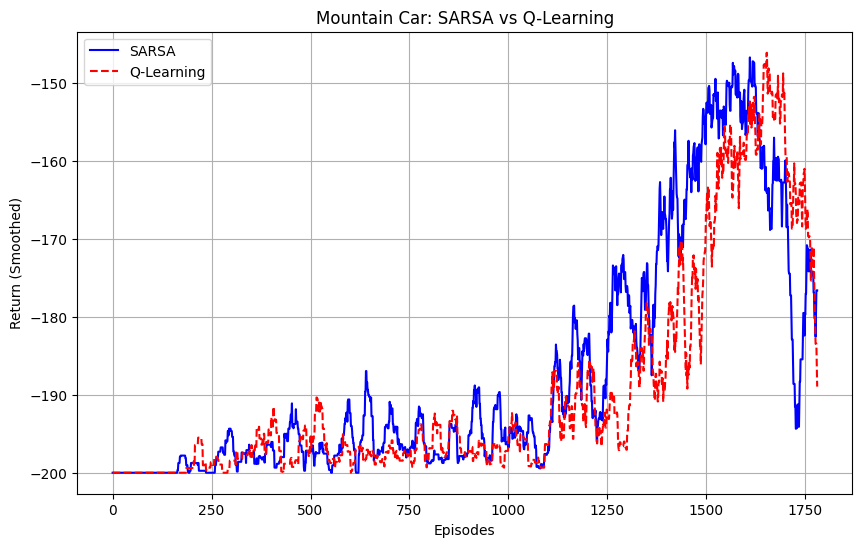

In [79]:
plt.figure(figsize=(10, 6))
window = 20
plt.plot(np.convolve(sarsa_returns, np.ones(window)/window, mode='valid'), label='SARSA', color='blue')
plt.plot(np.convolve(q_returns, np.ones(window)/window, mode='valid'), label='Q-Learning', color='red', linestyle='--')
plt.xlabel('Episodes')
plt.ylabel('Return (Smoothed)')
plt.title('Mountain Car: SARSA vs Q-Learning')
plt.legend()
plt.grid(True)
plt.show()

The code block below is to show the actual rendering of the agent performance. 

In [80]:
#Run this block to see the agent in action!

import matplotlib.pyplot as plt
from IPython.display import display, clear_output

print("Spawning inline test environment...")
render_env = gym.make("MountainCar-v0", render_mode="rgb_array")
fig, ax = plt.subplots(figsize=(6, 4))

def watch_agent(agent, agent_name):
    agent.epsilon = 0.0  
    state, _ = render_env.reset()
    done = False
    
    print(f"--- Now rendering {agent_name} ---")
    
    while not done:
        action = agent.act(state)
        state, _, terminated, truncated, _ = render_env.step(action)
        done = terminated or truncated
        

        frame = render_env.render()
        

        ax.clear()
        ax.imshow(frame)
        ax.axis('off')
        display(fig)
        clear_output(wait=True)


watch_agent(sarsa_agent, "SARSA")
watch_agent(q_agent, "Q-Learning")

# 3. Clean up
render_env.close()
plt.close(fig)
print("Testing complete for both agents!")


Testing complete for both agents!


## Tile Coding

Radia Basis Functions are a direct generalization of Tile Coding. Let us see how the agents fare in this environment.

In [49]:
from utils.features import TileCoder
env = gym.make("MountainCar-v0")
min_feat = env.observation_space.low
max_feat = env.observation_space.high

num_tiles = 8
num_bins = 8

displacement = (max_feat - min_feat) / (num_bins * num_tiles)

tile_extractor = TileCoder(
    min_features=min_feat, 
    max_features=max_feat, 
    num_tiles=num_tiles, 
    num_bins=num_bins, 
    displacement=displacement
)

alpha = 0.1 / num_tiles
gamma = 0.99
epsilon_start = 1.0  
episodes = 190

sarsa_agent = Sarsa(env.action_space.n, tile_extractor, alpha, gamma, epsilon_start)
q_agent = QLearning(env.action_space.n, tile_extractor, alpha, gamma, epsilon_start)

print("--- Training SARSA (Tile Coding) ---")
sarsa_returns_tc = train_agent(env, sarsa_agent, episodes, epsilon_decay=0.995)

print("\n--- Training Q-Learning (Tile Coding) ---")
q_returns_tc = train_agent(env, q_agent, episodes, epsilon_decay=0.995)

env.close()

--- Training SARSA (Tile Coding) ---


Training Episodes: 100%|██████████| 190/190 [00:02<00:00, 89.35it/s, Return=-200, Eps=0.39]



--- Training Q-Learning (Tile Coding) ---


Training Episodes: 100%|██████████| 190/190 [00:02<00:00, 83.52it/s, Return=-200, Eps=0.39]


It can be seen below that SARSA converges faster than Q learning. This is more so because SARSA does not really take unnecessary risks. In the long term however, Q learning will find the best optimal path. An idea is that theoretically speaking, it is perhaps not the best idea to choose the greedy strategy at the very start, in this case it is more beneficial to build momentum by making the car go up (to the left), and Q-learning takes time to learn this. In fact, if we reduce epsilon, we see that Q learning continues to do even more terribly than SARSA. 

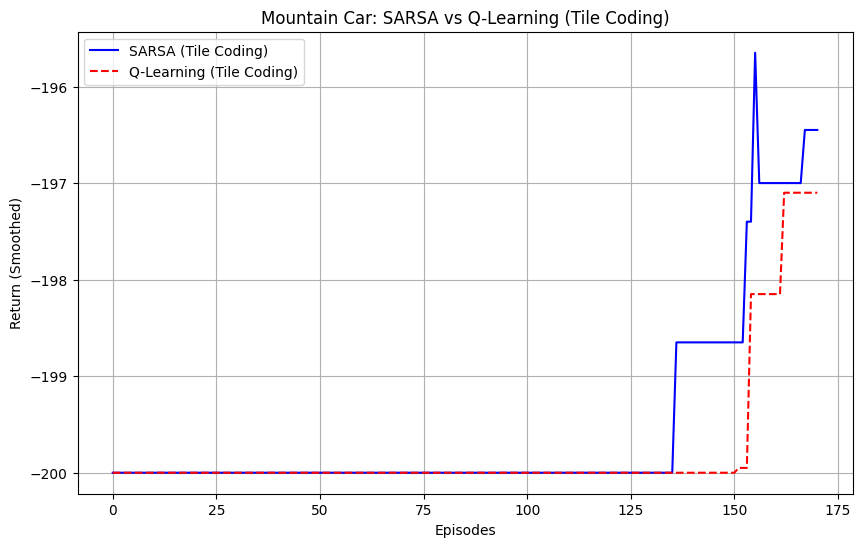

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
window = 20
plt.plot(np.convolve(sarsa_returns_tc, np.ones(window)/window, mode='valid'), label='SARSA (Tile Coding)', color='blue')
plt.plot(np.convolve(q_returns_tc, np.ones(window)/window, mode='valid'), label='Q-Learning (Tile Coding)', color='red', linestyle='--')
plt.xlabel('Episodes')
plt.ylabel('Return (Smoothed)')
plt.title('Mountain Car: SARSA vs Q-Learning (Tile Coding)')
plt.legend()
plt.grid(True)
plt.show()

In [51]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import gymnasium as gym

print("Spawning inline test environment...")
render_env = gym.make("MountainCar-v0", render_mode="rgb_array")
fig, ax = plt.subplots(figsize=(6, 4))

def watch_agent(agent, agent_name):
    """Helper function to test and render a specific agent."""
    agent.epsilon = 0.0 
    state, _ = render_env.reset()
    done = False
    
    print(f"--- Now rendering {agent_name} ---")
    
    while not done:
        action = agent.act(state)
        state, _, terminated, truncated, _ = render_env.step(action)
        done = terminated or truncated
        

        frame = render_env.render()
        ax.clear()
        ax.imshow(frame)
        ax.axis('off')
        display(fig)
        clear_output(wait=True)


watch_agent(sarsa_agent, "SARSA (Tile Coding)")

watch_agent(q_agent, "Q-Learning (Tile Coding)")

render_env.close()
plt.close(fig)
print("Tile Coding evaluation complete!")

Tile Coding evaluation complete!
